# OhioT1DM - Exploratory Data Analysis
**Purpose:** Understand the dataset structure, glucose dynamics,
physiological feature distributions, stationarity, and feature-target correlations
before any modelling is performed.

> This notebook is **EDA only**. All modelling lives in `main.py` and `src/models/`.


In [1]:
import os
import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

def find_project_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "configs" / "config.yaml").exists() and (path / "src").exists():
            return path
    raise FileNotFoundError("Could not find project root containing configs/config.yaml and src/")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from src.utils.config_loader import load_config
from src.utils.seed import set_global_seed

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 100

cfg = load_config(PROJECT_ROOT / "configs" / "config.yaml")
set_global_seed(cfg["seed"])

PROCESSED_DIR = PROJECT_ROOT / "output" / "processed"
PLOTS_DIR = PROJECT_ROOT / cfg["paths"]["plots_dir"]
RESULTS_DIR = PROJECT_ROOT / cfg["paths"]["results_dir"]
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Config loaded. Processed data dir:", PROCESSED_DIR)


Config loaded. Processed data dir: C:\Users\Admin\Desktop\blood-glucose-prediction\output\processed


## 1. Load Processed DataFrames


In [2]:
def load_processed_split(split: str, processed_dir: Path) -> dict[str, pd.DataFrame]:
    split_dir = processed_dir / split
    files = sorted(split_dir.glob(f"*_{split}_master.csv"))
    if not files:
        raise FileNotFoundError(
            f"No processed {split} master CSVs found in {split_dir}. "
            "Run: python scripts/export_master_dataframes.py"
        )

    masters = {}
    suffix = f"_{split}_master.csv"
    for file in files:
        patient_key = file.name.removesuffix(suffix)
        df = pd.read_csv(file, parse_dates=["ts"]).set_index("ts").sort_index()
        df["patient"] = patient_key
        df["split"] = split
        masters[patient_key] = df
    return masters


train_masters = load_processed_split("train", PROCESSED_DIR)
test_masters = load_processed_split("test", PROCESSED_DIR)
split_masters = {"train": train_masters, "test": test_masters}

patient_keys = sorted(set(train_masters) | set(test_masters))
combined_masters = {}
for key in patient_keys:
    parts = [df for df in [train_masters.get(key), test_masters.get(key)] if df is not None]
    combined_masters[key] = pd.concat(parts).sort_index()

all_data = pd.concat(combined_masters.values()).sort_index()
all_data = all_data.drop(columns = "raw_glucose_level")

print(f"Train master DataFrames: {len(train_masters)}")
print(f"Test master DataFrames:  {len(test_masters)}")
print(f"Patients loaded:          {len(patient_keys)}")
print(f"Rows available for aggregate analysis: {len(all_data):,}")
display(all_data.head())


Train master DataFrames: 12
Test master DataFrames:  12
Patients loaded:          12
Rows available for aggregate analysis: 188,959


,glucose_level,bolus,meal,basal,exercise,basis_gsr,finger_stick,basis_skin_temperature,basis_sleep,total_insulin,insulin_count,insulin_3h_std,daily_exercise,patient,split
ts,,,,,,,,,,,,,,,
2021-08-30 11:55:00,116.0,3.0,0.0,1.143333,0.0,0.000065,160.0,88.356364,0.0,3.095278,1.0,0.000000,1,588_2018,train
2021-08-30 12:00:00,117.0,0.0,37.0,1.143333,0.0,0.000066,114.0,91.400000,0.0,0.095278,0.0,2.121320,1,588_2018,train
2021-08-30 12:05:00,119.0,5.1,0.0,1.143333,0.0,0.000066,114.0,91.400000,0.0,5.195278,1.0,2.563201,1,588_2018,train
2021-08-30 12:10:00,116.0,0.0,0.0,1.143333,0.0,0.000066,114.0,91.940000,0.0,0.095278,0.0,2.490482,1,588_2018,train
2021-08-30 12:15:00,111.0,0.0,0.0,1.143333,0.0,0.000067,114.0,93.200000,0.0,0.095278,0.0,2.339231,1,588_2018,train


## 2. Glucose Visualisation


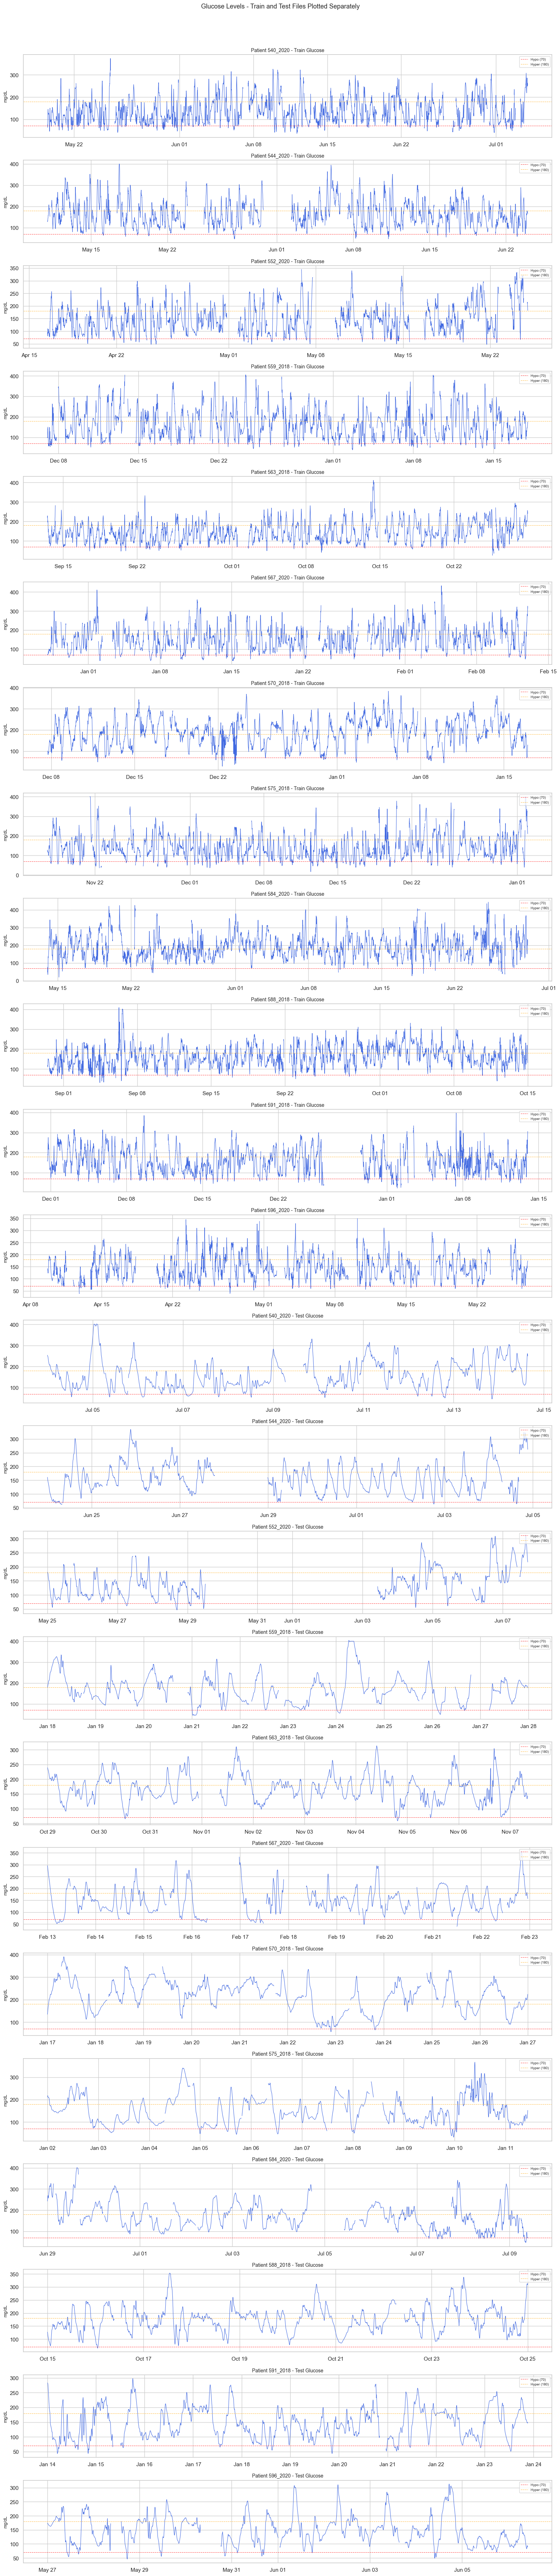

In [3]:
plot_items = [
    (split, key, df)
    for split, masters in split_masters.items()
    for key, df in sorted(masters.items())
]

n = len(plot_items)
fig, axes = plt.subplots(n, 1, figsize=(16, 3 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, (split, key, df) in zip(axes, plot_items):
    ax.plot(df.index, df["glucose_level"], lw=0.8, color="royalblue")
    ax.axhline(70, ls="--", color="red", lw=0.8, alpha=0.7, label="Hypo (70)")
    ax.axhline(180, ls="--", color="orange", lw=0.8, alpha=0.7, label="Hyper (180)")
    ax.set_ylabel("mg/dL", fontsize=9)
    ax.set_title(f"Patient {key} - {split.title()} Glucose", fontsize=10)
    ax.legend(fontsize=7, loc="upper right")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.suptitle("Glucose Levels - Train and Test Files Plotted Separately", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_glucose.png"), bbox_inches="tight")
plt.show()


## 3. Glucose Distribution per Patient


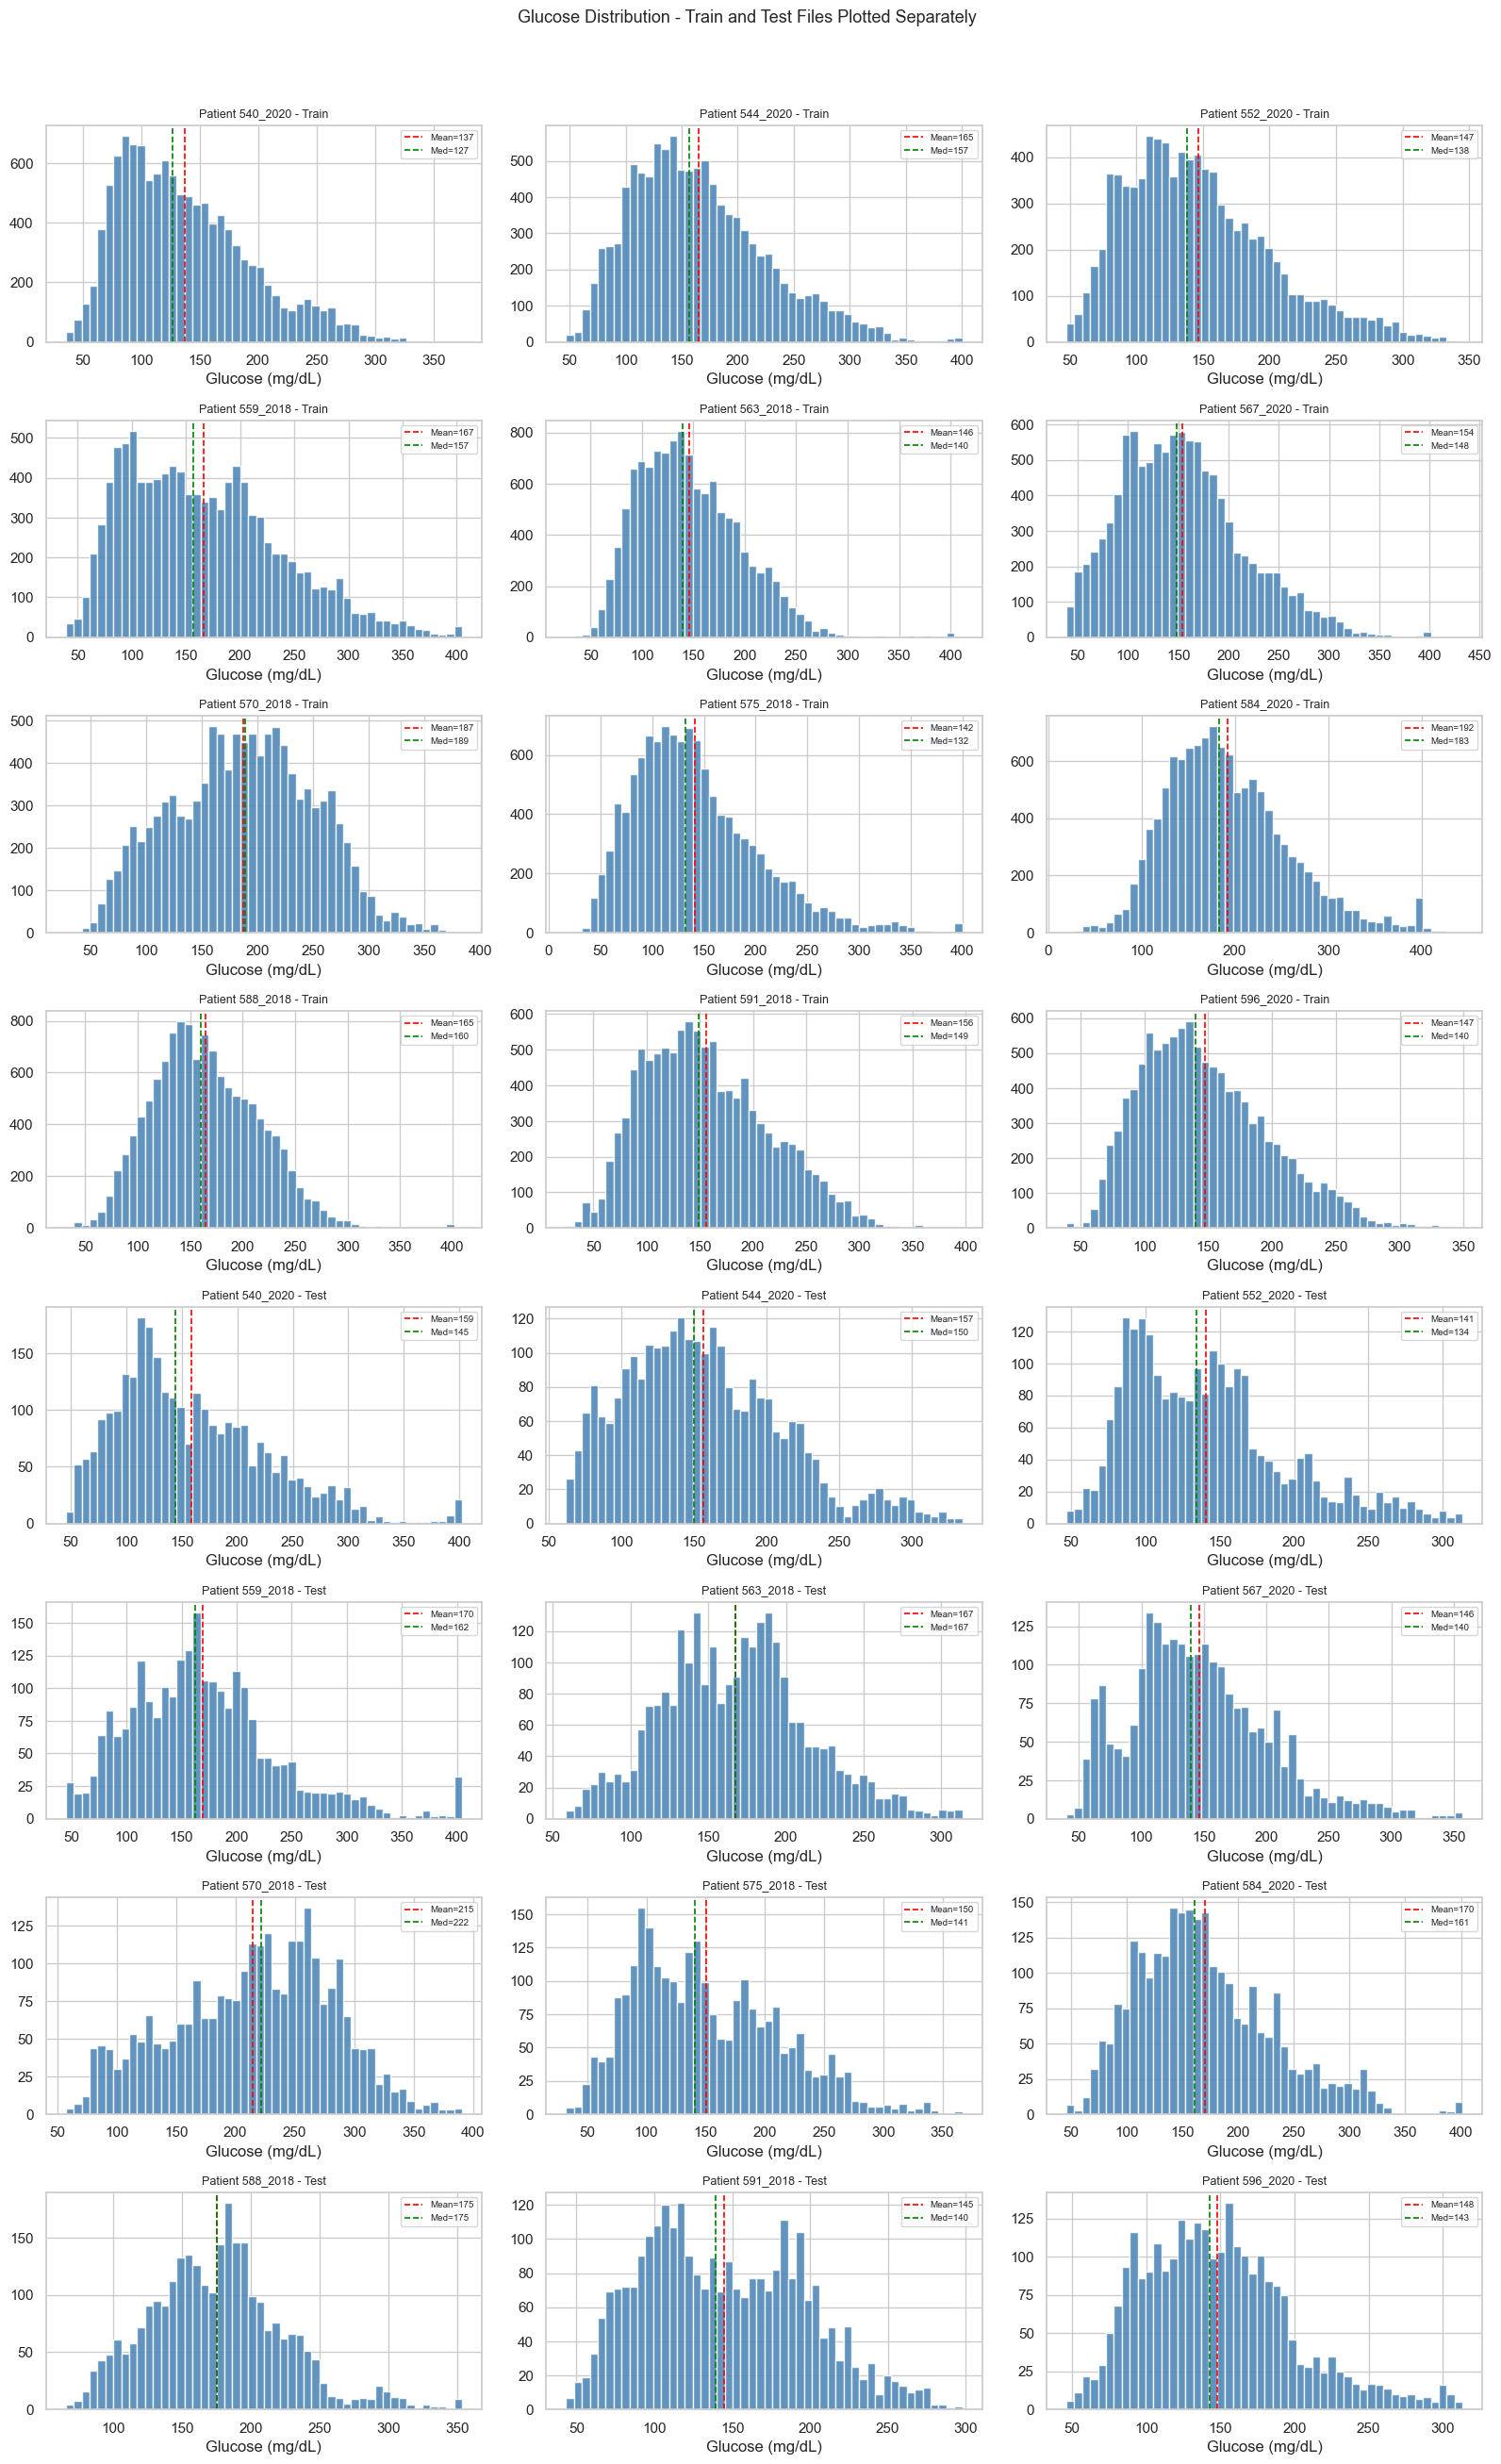

In [4]:
plot_items = [
    (split, key, df)
    for split, masters in split_masters.items()
    for key, df in sorted(masters.items())
]

n = len(plot_items)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, (split, key, df) in enumerate(plot_items):
    gl = df["glucose_level"].dropna()
    axes[i].hist(gl, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].axvline(gl.mean(), color="red", ls="--", lw=1.2, label=f"Mean={gl.mean():.0f}")
    axes[i].axvline(gl.median(), color="green", ls="--", lw=1.2, label=f"Med={gl.median():.0f}")
    axes[i].set_title(f"Patient {key} - {split.title()}", fontsize=9)
    axes[i].set_xlabel("Glucose (mg/dL)")
    axes[i].legend(fontsize=7)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Glucose Distribution - Train and Test Files Plotted Separately", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_glucose_distributions.png"), bbox_inches="tight")
plt.show()


## 4. Time-in-Range (TIR) Analysis


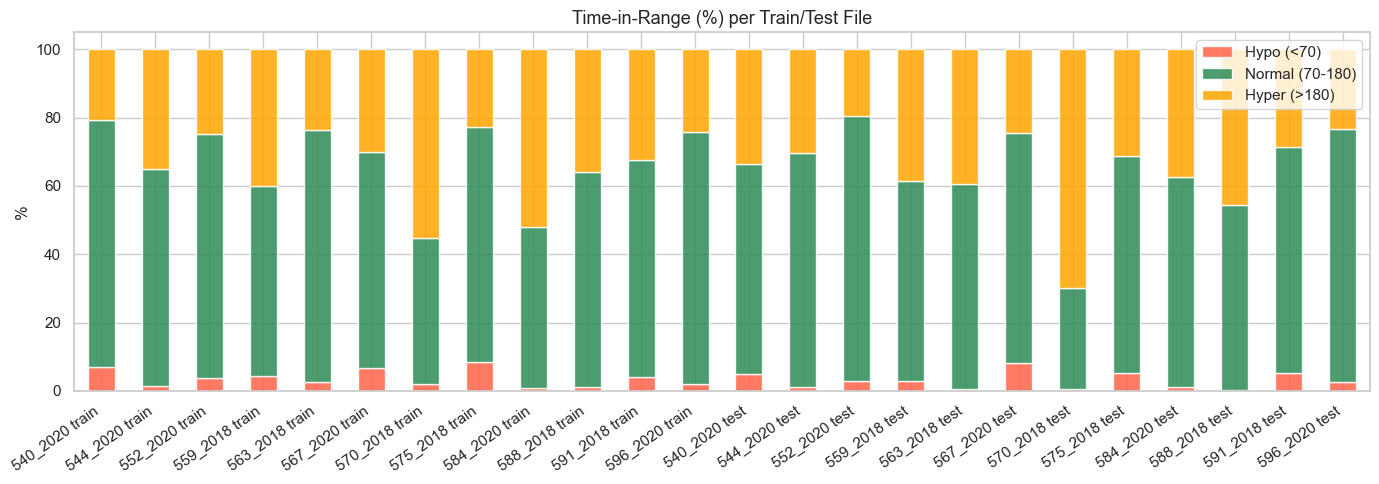

          file  patient split  hypo_pct  normal_pct  hyper_pct
540_2020 train 540_2020 train  7.064535   72.177116  20.758349
544_2020 train 544_2020 train  1.515579   63.353102  35.131319
552_2020 train 552_2020 train  3.700441   71.530837  24.768722
559_2018 train 559_2018 train  4.242312   55.631715  40.125973
563_2018 train 563_2018 train  2.556912   73.696800  23.746288
567_2020 train 567_2020 train  6.529748   63.556824  29.913428
570_2018 train 570_2018 train  1.975961   42.633400  55.390639
575_2018 train 575_2018 train  8.486432   68.708916  22.804652
584_2020 train 584_2020 train  0.897193   47.106758  51.996049
588_2018 train 588_2018 train  1.155063   63.037975  35.806962
591_2018 train 591_2018 train  4.074859   63.667373  32.257767
596_2020 train 596_2020 train  2.114554   73.751954  24.133493
 540_2020 test 540_2020  test  4.903315   61.533149  33.563536
 544_2020 test 544_2020  test  1.215022   68.409426  30.375552
 552_2020 test 552_2020  test  2.749577   77.791878  19

In [5]:
tir_records = []
for split, masters in split_masters.items():
    for key, df in sorted(masters.items()):
        gl = df["glucose_level"].dropna()
        total = len(gl)
        if total == 0:
            continue
        tir_records.append(dict(
            file=f"{key} {split}",
            patient=key,
            split=split,
            hypo_pct=(gl < 70).sum() / total * 100,
            normal_pct=((gl >= 70) & (gl <= 180)).sum() / total * 100,
            hyper_pct=(gl > 180).sum() / total * 100,
        ))

tir_df = pd.DataFrame(tir_records)
ax = tir_df.set_index("file")[["hypo_pct", "normal_pct", "hyper_pct"]].plot(
    kind="bar", stacked=True, figsize=(14, 5),
    color=["tomato", "seagreen", "orange"], alpha=0.85,
)
ax.set_title("Time-in-Range (%) per Train/Test File", fontsize=13)
ax.set_ylabel("%")
ax.set_xlabel("")
ax.legend(["Hypo (<70)", "Normal (70-180)", "Hyper (>180)"], loc="upper right")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_time_in_range.png"), bbox_inches="tight")
plt.show()
print(tir_df.to_string(index=False))


## 5. Stationarity Check (ADF Test)


In [6]:
ADF_ALPHA = 0.05
ADF_INTERPOLATE_LIMIT = cfg["feature_engineering"].get("interpolate_limit", 6)


def prepare_adf_series(df: pd.DataFrame, col: str) -> pd.Series:
    """ADF needs a one-dimensional, regular, finite series."""
    return (
        pd.to_numeric(df[col], errors="coerce")
        .resample("5min")
        .mean()
        .interpolate(limit=ADF_INTERPOLATE_LIMIT, limit_area="inside")
        .dropna()
    )


adf_records = []
for split, masters in split_masters.items():
    for key, df in sorted(masters.items()):
        for col in ["glucose_level", "raw_glucose_level"]:
            if col not in df.columns:
                continue
            series = prepare_adf_series(df, col)
            if len(series) < 20 or series.nunique() <= 1:
                continue

            adf_stat, p_value, used_lag, n_obs, critical_values, ic_best = adfuller(
                series,
                regression="c",
                autolag="AIC",
            )
            adf_records.append(dict(
                patient=key,
                split=split,
                series=col,
                n_obs=n_obs,
                used_lag=used_lag,
                adf_stat=round(adf_stat, 4),
                p_value=p_value,
                crit_5pct=round(critical_values["5%"], 4),
                stationary="Yes" if p_value < ADF_ALPHA else "No",
            ))

adf_df = pd.DataFrame(adf_records)
print("Augmented Dickey-Fuller test: H0 = unit root / non-stationary")
print(f"Decision rule: stationary if p < {ADF_ALPHA} and ADF statistic is below the critical value.")
display(adf_df.sort_values(["series", "split", "patient"]))

print("Stationary counts by series and split:")
display(pd.crosstab([adf_df["series"], adf_df["split"]], adf_df["stationary"]))


Augmented Dickey-Fuller test: H0 = unit root / non-stationary
Decision rule: stationary if p < 0.05 and ADF statistic is below the critical value.


,patient,split,series,n_obs,used_lag,adf_stat,p_value,crit_5pct,stationary
24,540_2020,test,glucose_level,2926,13,-6.5422,9.285894e-09,-2.8625,Yes
26,544_2020,test,glucose_level,2728,15,-6.5146,1.079176e-08,-2.8626,Yes
28,552_2020,test,glucose_level,2401,13,-5.0153,2.069756e-05,-2.8627,Yes
30,559_2018,test,glucose_level,2552,20,-5.8841,3.029607e-07,-2.8627,Yes
32,563_2018,test,glucose_level,2555,24,-6.6456,5.274027e-09,-2.8627,Yes
34,567_2020,test,glucose_level,2447,4,-8.0720,1.540249e-12,-2.8627,Yes
36,570_2018,test,glucose_level,2778,14,-4.7482,6.824268e-05,-2.8626,Yes
38,575_2018,test,glucose_level,2614,26,-5.5129,1.954096e-06,-2.8626,Yes
40,584_2020,test,glucose_level,2738,9,-6.9120,1.205555e-09,-2.8626,Yes
42,588_2018,test,glucose_level,2789,13,-7.2289,2.018759e-10,-2.8626,Yes


Stationary counts by series and split:


stationary               Yes
series            split     
glucose_level     test    12
                  train   12
raw_glucose_level test    12
                  train   12

## 6. ACF & PACF for a Representative Patient


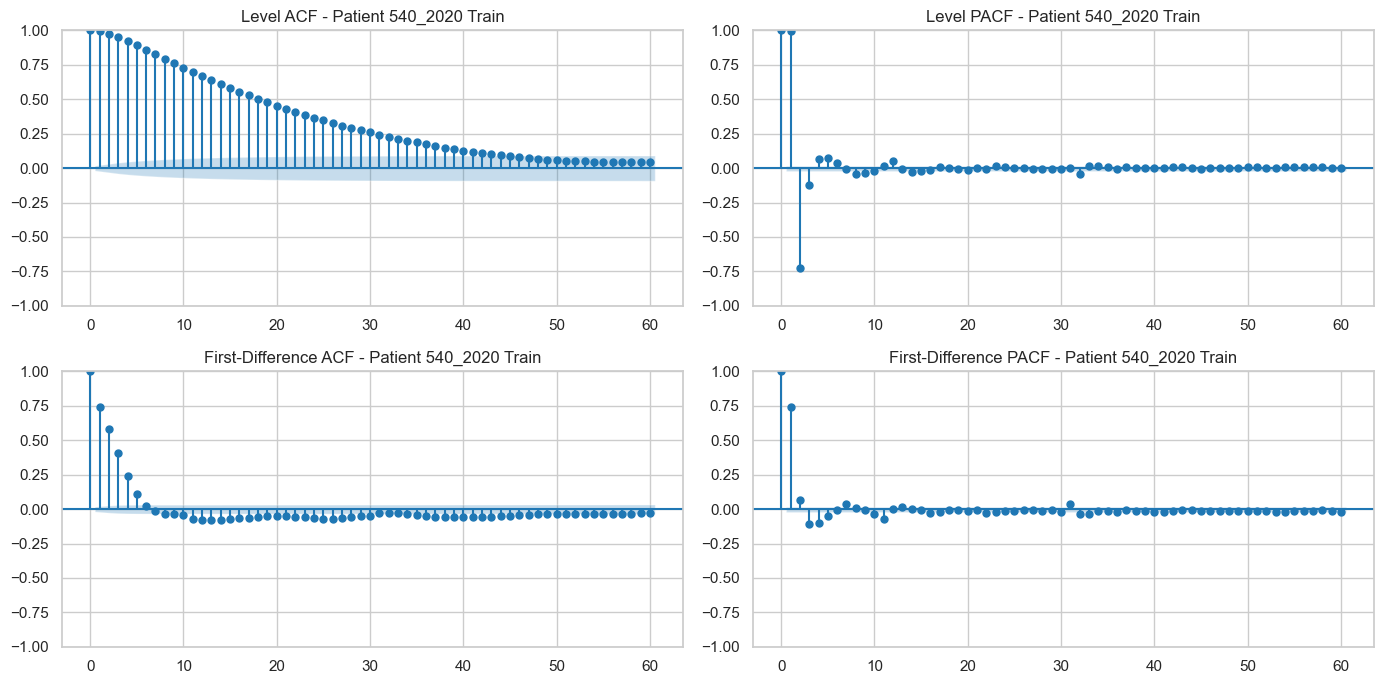

Patient 540_2020 train ADF p-value = 8.02e-24. A slow-decaying level ACF indicates strong glucose persistence/autocorrelation; it does not by itself prove a unit root when the ADF test rejects H0.


In [7]:
sample_key = sorted(train_masters.keys())[0]
gl_series = (
    prepare_adf_series(train_masters[sample_key], "glucose_level")
)
gl_diff = gl_series.diff().dropna()
sample_adf = adfuller(gl_series, regression="c", autolag="AIC")

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
plot_acf(gl_series, lags=60, ax=axes[0, 0], title=f"Level ACF - Patient {sample_key} Train")
plot_pacf(gl_series, lags=60, ax=axes[0, 1], title=f"Level PACF - Patient {sample_key} Train")
plot_acf(gl_diff, lags=60, ax=axes[1, 0], title=f"First-Difference ACF - Patient {sample_key} Train")
plot_pacf(gl_diff, lags=60, ax=axes[1, 1], title=f"First-Difference PACF - Patient {sample_key} Train")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_acf_pacf.png"), bbox_inches="tight")
plt.show()

print(
    f"Patient {sample_key} train ADF p-value = {sample_adf[1]:.3g}. "
    "A slow-decaying level ACF indicates strong glucose persistence/autocorrelation; "
    "it does not by itself prove a unit root when the ADF test rejects H0."
)


## 7. Processed Feature Correlation Analysis


In [8]:
numeric_cols = all_data.select_dtypes(include=[np.number]).columns
feature_cols = [col for col in numeric_cols if col != "glucose_level"]

print(f"Feature columns compared with glucose_level ({len(feature_cols)}):")
print(feature_cols)


Feature columns compared with glucose_level (12):
['bolus', 'meal', 'basal', 'exercise', 'basis_gsr', 'finger_stick', 'basis_skin_temperature', 'basis_sleep', 'total_insulin', 'insulin_count', 'insulin_3h_std', 'daily_exercise']


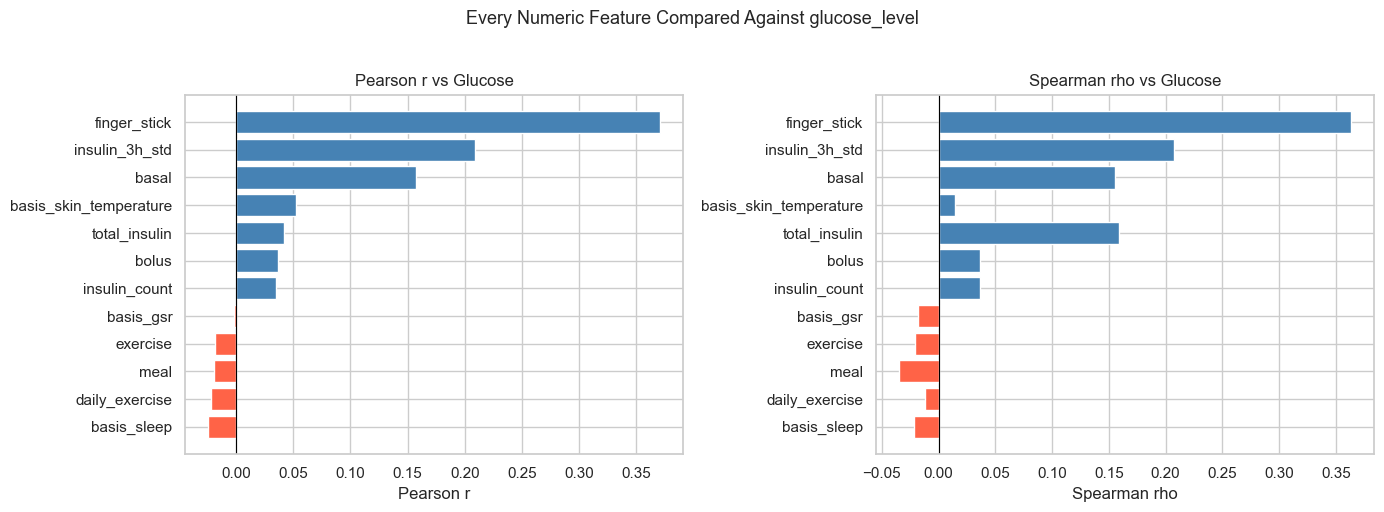


Pearson:


,r,p-value
basis_sleep,-0.0244,0.0000
daily_exercise,-0.0220,0.0000
meal,-0.0194,0.0000
exercise,-0.0184,0.0000
basis_gsr,-0.0020,0.4167
insulin_count,0.0350,0.0000
bolus,0.0365,0.0000
total_insulin,0.0416,0.0000
basis_skin_temperature,0.0524,0.0000
basal,0.1578,0.0000



Spearman:


,r,p-value
basis_sleep,-0.0219,0.0
daily_exercise,-0.0119,0.0
meal,-0.0349,0.0
exercise,-0.0212,0.0
basis_gsr,-0.0184,0.0
insulin_count,0.0368,0.0
bolus,0.0368,0.0
total_insulin,0.1586,0.0
basis_skin_temperature,0.0148,0.0
basal,0.1558,0.0


In [9]:
pearson_r, spearman_r = {}, {}

corr_data = all_data.dropna(subset=["glucose_level"])
for col in feature_cols:
    valid = corr_data[[col, "glucose_level"]].dropna()
    if len(valid) < 3 or valid[col].nunique() <= 1:
        continue
    r, p = stats.pearsonr(valid[col], valid["glucose_level"])
    pearson_r[col] = (round(r, 4), round(p, 4))
    r2, p2 = stats.spearmanr(valid[col], valid["glucose_level"])
    spearman_r[col] = (round(r2, 4), round(p2, 4))

pearson_df = pd.DataFrame(pearson_r, index=["r", "p-value"]).T.sort_values("r")
spearman_df = pd.DataFrame(spearman_r, index=["r", "p-value"]).T.reindex(pearson_df.index)

fig_height = max(5, 0.35 * max(1, len(pearson_df)))
fig, axes = plt.subplots(1, 2, figsize=(14, fig_height))

for ax, corr_df, title, xlabel in [
    (axes[0], pearson_df, "Pearson r vs Glucose", "Pearson r"),
    (axes[1], spearman_df, "Spearman rho vs Glucose", "Spearman rho"),
]:
    if corr_df.empty:
        ax.text(0.5, 0.5, "No valid feature correlations", ha="center", va="center")
        ax.set_axis_off()
        continue
    colors = ["steelblue" if v >= 0 else "tomato" for v in corr_df["r"]]
    ax.barh(corr_df.index, corr_df["r"], color=colors)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel)

plt.suptitle("Every Numeric Feature Compared Against glucose_level", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_correlation.png"), bbox_inches="tight")
plt.show()

print("\nPearson:"); display(pearson_df)
print("\nSpearman:"); display(spearman_df)


## 8. Engineered Feature Distributions


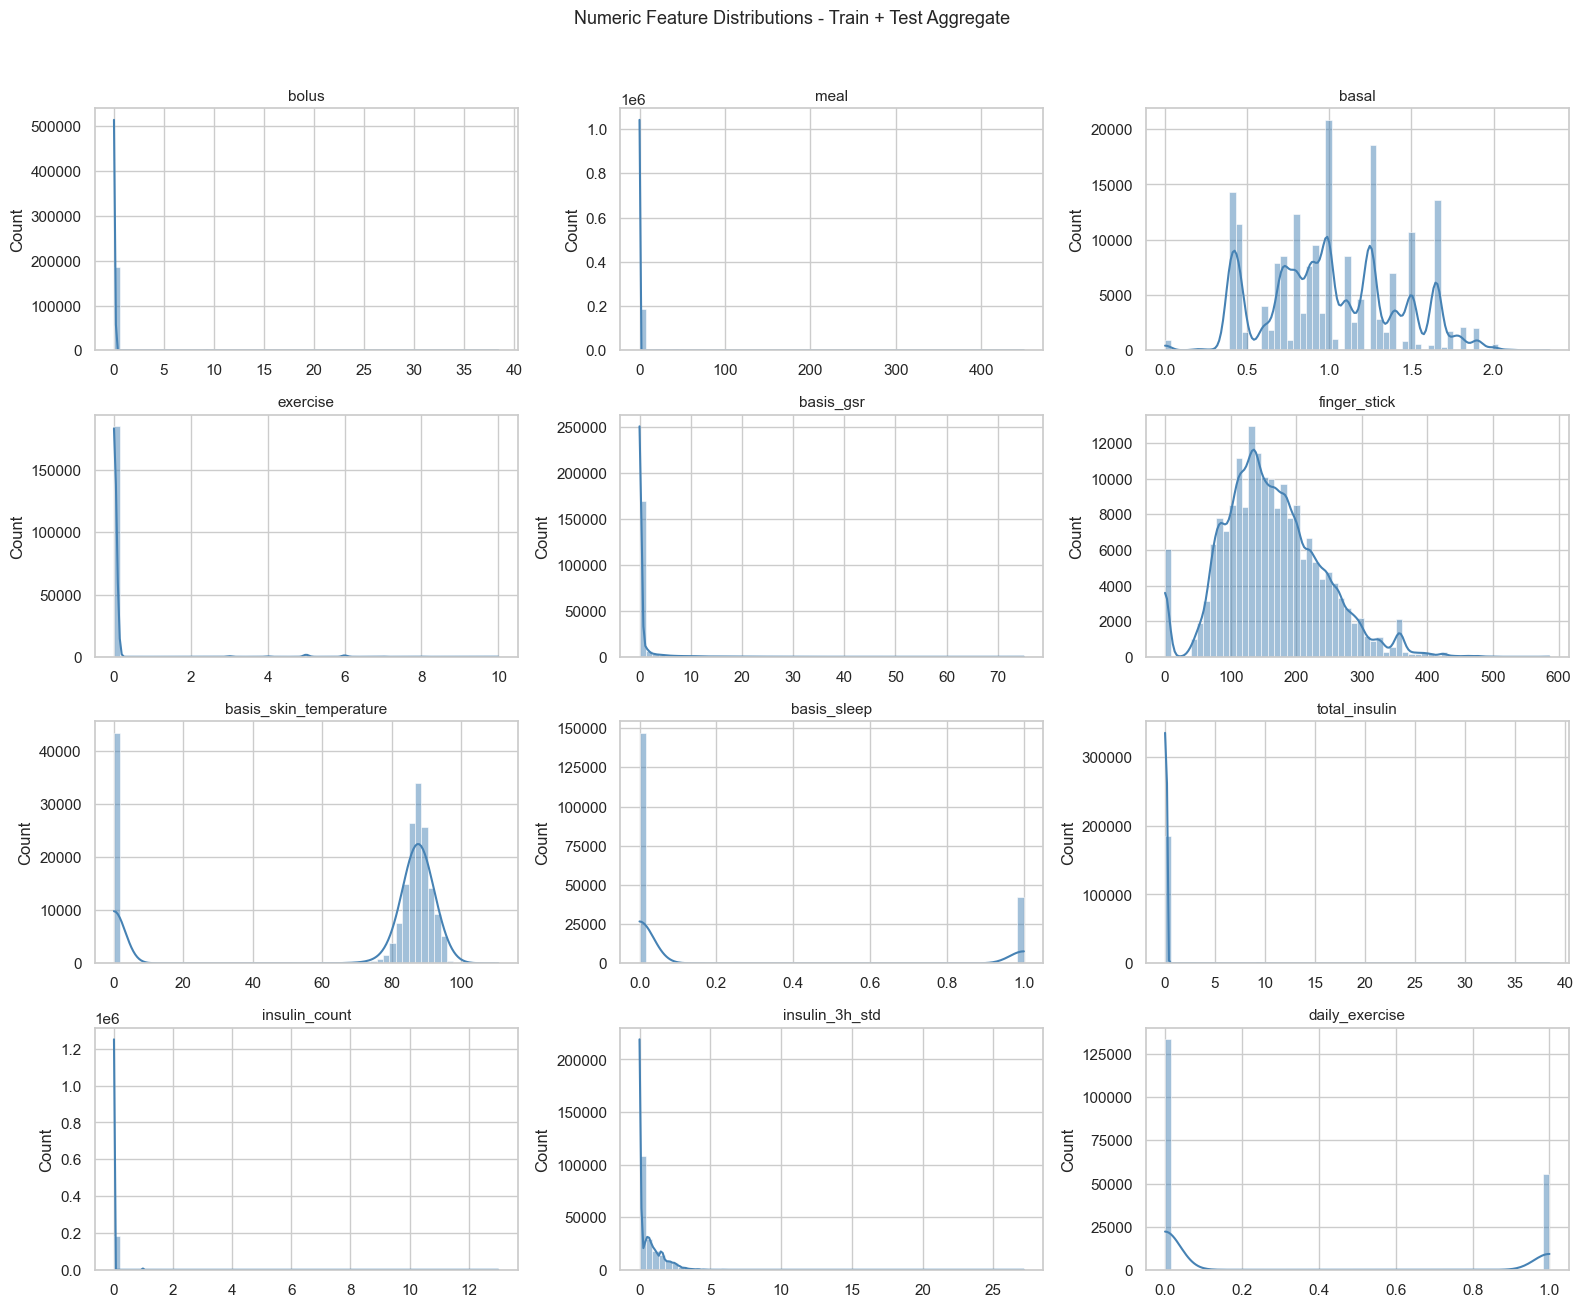

In [10]:
n = len(feature_cols)
ncols = 3
nrows = int(np.ceil(max(1, n) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, feature_cols):
    data = all_data[col].dropna()
    sns.histplot(data, bins=60, ax=ax, color="steelblue", kde=True)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")

for ax in axes[len(feature_cols):]:
    ax.set_visible(False)

plt.suptitle("Numeric Feature Distributions - Train + Test Aggregate", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_feature_distributions.png"), bbox_inches="tight")
plt.show()


## 9. Insulin vs Glucose Relationship


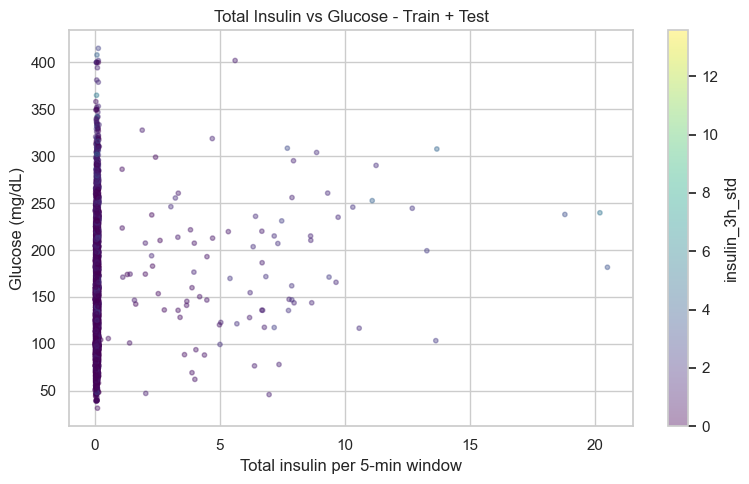

In [11]:
sample = all_data.sample(min(5000, len(all_data)), random_state=42)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    sample["total_insulin"],
    sample["glucose_level"],
    c=sample["insulin_3h_std"],
    cmap="viridis",
    alpha=0.4,
    s=10,
)
plt.colorbar(sc, ax=ax, label="insulin_3h_std")
ax.set_xlabel("Total insulin per 5-min window")
ax.set_ylabel("Glucose (mg/dL)")
ax.set_title("Total Insulin vs Glucose - Train + Test")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_insulin_glucose_scatter.png"), bbox_inches="tight")
plt.show()


## 10. Summary Statistics for Final DataFrames


In [12]:
summary = all_data.drop(columns=["patient", "split"], errors="ignore").describe().T
display(summary)
summary.to_csv(RESULTS_DIR / "eda_summary_stats.csv")
print("EDA complete. Plots saved to:", PLOTS_DIR)


,count,mean,std,min,25%,50%,75%,max
glucose_level,166532.0,159.580689,60.985753,16.783217,113.314685,151.860140,197.272727,444.027972
bolus,188959.0,0.117561,1.044392,0.000000,0.000000,0.000000,0.000000,38.400000
meal,188959.0,0.520822,6.091661,0.000000,0.000000,0.000000,0.000000,450.000000
basal,188959.0,1.012927,0.398905,0.000000,0.730000,0.980000,1.250000,2.340000
exercise,188959.0,0.108103,0.761866,0.000000,0.000000,0.000000,0.000000,10.000000
basis_gsr,188959.0,0.811079,3.518468,0.000000,0.000056,0.000156,0.096163,75.074351
finger_stick,188959.0,163.032525,74.902415,0.000000,113.000000,155.000000,208.000000,586.000000
basis_skin_temperature,188959.0,67.275295,36.938756,0.000000,79.520000,86.236000,88.880000,110.660000
basis_sleep,188959.0,0.222218,0.415738,0.000000,0.000000,0.000000,0.000000,1.000000
total_insulin,188959.0,0.201971,1.045232,0.000000,0.060833,0.083333,0.104167,38.441667


EDA complete. Plots saved to: C:\Users\Admin\Desktop\blood-glucose-prediction\output\plots
